# 04 — Dự báo PM2.5: chia tập, so sánh và chọn mô hình

Notebook trình bày toàn bộ kết quả bước 12–13 cho dữ liệu Hà Nội theo giờ. Năm 2025 là **validation** để chọn giữa Baseline, Random Forest, XGBoost, LightGBM và LSTM. Tập **test 2026 chỉ được mở một lần** sau khi đã chọn mô hình.

Pipeline huấn luyện đầy đủ chạy bằng `python scripts/run_training.py --config config.yaml`. Notebook này đọc các artifact đã tạo để có thể chạy nhanh trong JupyterLab.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', palette='colorblind')
pd.set_option('display.max_columns', 20)
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
ARTIFACTS = ROOT / 'artifacts'

split_report = json.loads((ARTIFACTS / 'time_split_manifest.json').read_text(encoding='utf-8'))['report']
training_report = json.loads((ARTIFACTS / 'forecast_training_report.json').read_text(encoding='utf-8'))
validation_metrics = pd.read_csv(ARTIFACTS / 'forecast_validation_metrics.csv')
test_metrics = pd.read_csv(ARTIFACTS / 'forecast_test_metrics.csv')
predictions = pd.read_csv(ARTIFACTS / 'forecast_test_predictions.csv.gz')
predictions['timestamp'] = pd.to_datetime(predictions['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')

display(pd.Series({
    'Mô hình được chọn': training_report['selected_model'],
    'Tiêu chí chọn': training_report['protocol']['selection'],
    'Số horizon': len(training_report['horizons']),
    'Số mẫu validation so sánh': training_report['rows']['validation_comparable'],
    'Số mẫu test cuối cùng': training_report['rows']['test_comparable'],
}).to_frame('Giá trị'))

,Giá trị
Mô hình được chọn,LightGBM
Tiêu chí chọn,lowest mean validation MAE across horizons
Số horizon,3
Số mẫu validation so sánh,69848
Số mẫu test cuối cùng,28568


## 1. Chia train / validation / test theo thời gian

Dữ liệu không được shuffle. Pipeline purge 6 giờ cuối train và validation để nhãn `t+6h` không đi qua ranh giới tập.

In [2]:
total_assigned = sum(split_report[name]['rows'] for name in ['train', 'validation', 'test'])
split_summary = pd.DataFrame([
    {
        'Tập': name,
        'Số dòng': split_report[name]['rows'],
        'Tỷ lệ (%)': split_report[name]['rows'] / total_assigned * 100,
        'Số trạm': split_report[name]['stations'],
        'Bắt đầu': split_report[name]['start'],
        'Kết thúc': split_report[name]['end'],
    }
    for name in ['train', 'validation', 'test']
])
display(split_summary.round(2))

checks = split_report['chronology_checks']
assert all(checks.values()), checks
display(pd.Series({
    'Purge cuối train': split_report['train_boundary_rows_purged'],
    'Purge cuối validation': split_report['validation_boundary_rows_purged'],
    'Horizon tối đa (giờ)': split_report['max_target_horizon_hours'],
    'Tất cả kiểm tra chronology đạt': all(checks.values()),
}).to_frame('Giá trị'))

,Tập,Số dòng,Tỷ lệ (%),Số trạm,Bắt đầu,Kết thúc
0,train,167704,62.93,8,2022-08-11T07:00:00+07:00,2024-12-31T17:00:00+07:00
1,validation,70032,26.28,8,2025-01-01T00:00:00+07:00,2025-12-31T17:00:00+07:00
2,test,28752,10.79,8,2026-01-01T00:00:00+07:00,2026-05-30T17:00:00+07:00


,Giá trị
Purge cuối train,48
Purge cuối validation,48
Horizon tối đa (giờ),6
Tất cả kiểm tra chronology đạt,True


## 2. So sánh 5 mô hình trên validation

- **Baseline:** persistence — PM2.5 tương lai bằng PM2.5 hiện tại.
- **Random Forest, XGBoost, LightGBM:** nhận 113 đặc trưng số và 8 cột one-hot trạm.
- **LSTM:** chuỗi 24 giờ, 13 đặc trưng môi trường + mã trạm; StandardScaler chỉ fit trên train.
- Mọi mô hình được so sánh trên đúng 69.848 dòng validation có đủ cửa sổ LSTM. Mô hình thắng có **mean MAE thấp nhất qua 3 horizon**.

In [3]:
ranking = pd.DataFrame(training_report['validation_ranking'])
ranking.index = np.arange(1, len(ranking) + 1)
ranking.index.name = 'Hạng'
display(ranking.round(3))

display(
    validation_metrics.pivot(index='model', columns='horizon_hours', values=['MAE', 'RMSE', 'R2', 'MAPE'])
    .reindex(ranking['model'])
    .round(3)
)

,model,mean_MAE,mean_RMSE,mean_R2,mean_MAPE
Hạng,,,,,
1,LightGBM,8.987,13.576,0.787,18.648
2,XGBoost,9.078,13.720,0.783,19.086
3,RandomForest,9.700,14.572,0.762,20.137
4,LSTM,11.040,15.834,0.723,21.728
5,Baseline,13.436,19.833,0.535,28.370


MAE                   RMSE                     R2         \
horizon_hours      1       3       6      1       3       6      1      3   
model                                                                       
LightGBM       3.666   9.178  14.116  6.310  13.689  20.727  0.961  0.818   
XGBoost        3.685   9.305  14.245  6.380  13.963  20.816  0.960  0.811   
RandomForest   4.500   9.847  14.753  7.456  14.798  21.462  0.946  0.787   
LSTM           6.068  11.122  15.930  8.662  15.958  22.883  0.927  0.752   
Baseline       5.235  13.318  21.756  8.441  20.068  30.989  0.931  0.609   

                        MAPE                  
horizon_hours      6       1       3       6  
model                                         
LightGBM       0.582   7.125  18.869  29.950  
XGBoost        0.578   7.107  19.024  31.128  
RandomForest   0.551   8.372  20.012  32.029  
LSTM           0.490  11.769  21.721  31.693  
Baseline       0.065  10.253  27.510  47.347

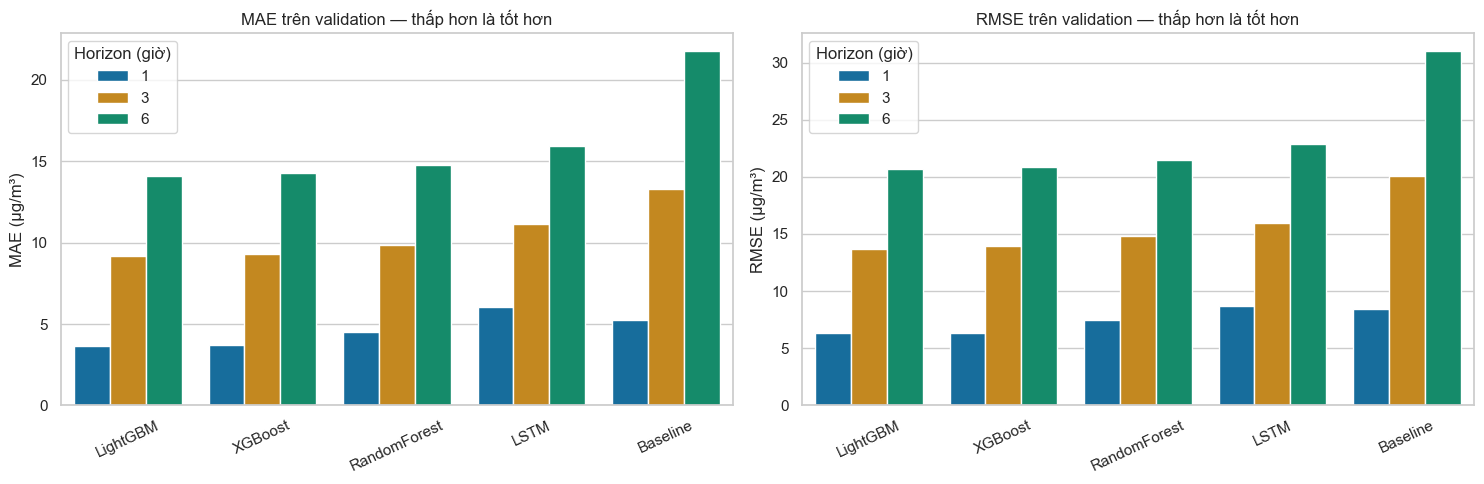

In [4]:
model_order = ranking['model'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    sns.barplot(
        data=validation_metrics, x='model', y=metric, hue='horizon_hours',
        order=model_order, ax=ax
    )
    ax.set_title(f'{metric} trên validation — thấp hơn là tốt hơn')
    ax.set_xlabel('')
    ax.set_ylabel(f'{metric} (µg/m³)')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Horizon (giờ)')
plt.tight_layout()
plt.show()

## 3. Learning curve của LSTM

Loss được tính trên target đã chuẩn hóa. Learning curve giúp kiểm tra việc học theo epoch; metric PM2.5 gốc vẫn nằm trong bảng validation phía trên.

,loss,mae,val_loss,val_mae
epoch,,,,
1,0.4508,0.4833,0.7894,0.6101
2,0.2731,0.3678,0.6393,0.5427
3,0.2383,0.3381,0.5713,0.5077
4,0.2200,0.3213,0.5274,0.4839
5,0.2080,0.3101,0.5064,0.4688
6,0.1984,0.3012,0.4958,0.4610


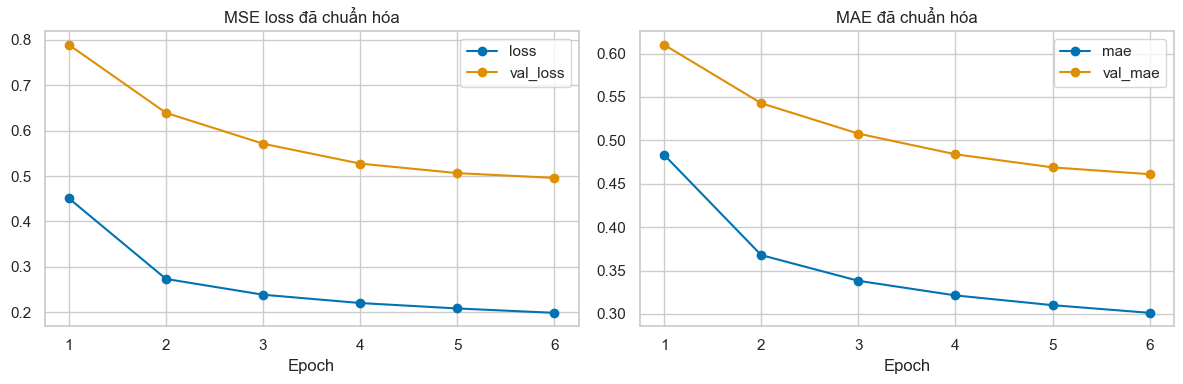

In [5]:
history = pd.DataFrame(training_report['lstm']['initial_history'])
history.index = np.arange(1, len(history) + 1)
history.index.name = 'epoch'
display(history.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history[['loss', 'val_loss']].plot(marker='o', ax=axes[0], title='MSE loss đã chuẩn hóa')
history[['mae', 'val_mae']].plot(marker='o', ax=axes[1], title='MAE đã chuẩn hóa')
for ax in axes:
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## 4. Đánh giá cuối cùng trên test

Sau khi LightGBM thắng validation, mô hình được fit lại bằng **train + validation** rồi đánh giá đúng một lần trên test từ 01/01/2026 đến 30/05/2026.

,model,Horizon (giờ),Số mẫu,MAE,RMSE,R2,MAPE
0,LightGBM,1,28568,3.178,5.724,0.966,6.527
1,LightGBM,3,28568,7.974,12.254,0.843,17.095
2,LightGBM,6,28568,12.277,17.584,0.677,28.635


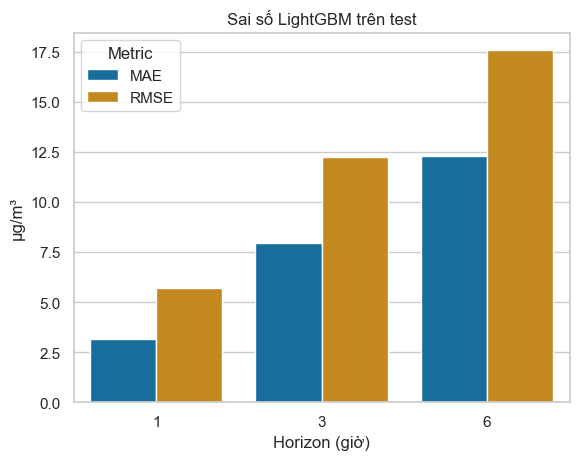

In [6]:
display(
    test_metrics[['model', 'horizon_hours', 'samples', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .rename(columns={'horizon_hours': 'Horizon (giờ)', 'samples': 'Số mẫu'})
    .round(3)
)

test_long = test_metrics.melt(
    id_vars=['horizon_hours'], value_vars=['MAE', 'RMSE'],
    var_name='Metric', value_name='Giá trị'
)
ax = sns.barplot(data=test_long, x='horizon_hours', y='Giá trị', hue='Metric')
ax.set(title='Sai số LightGBM trên test', xlabel='Horizon (giờ)', ylabel='µg/m³')
plt.show()

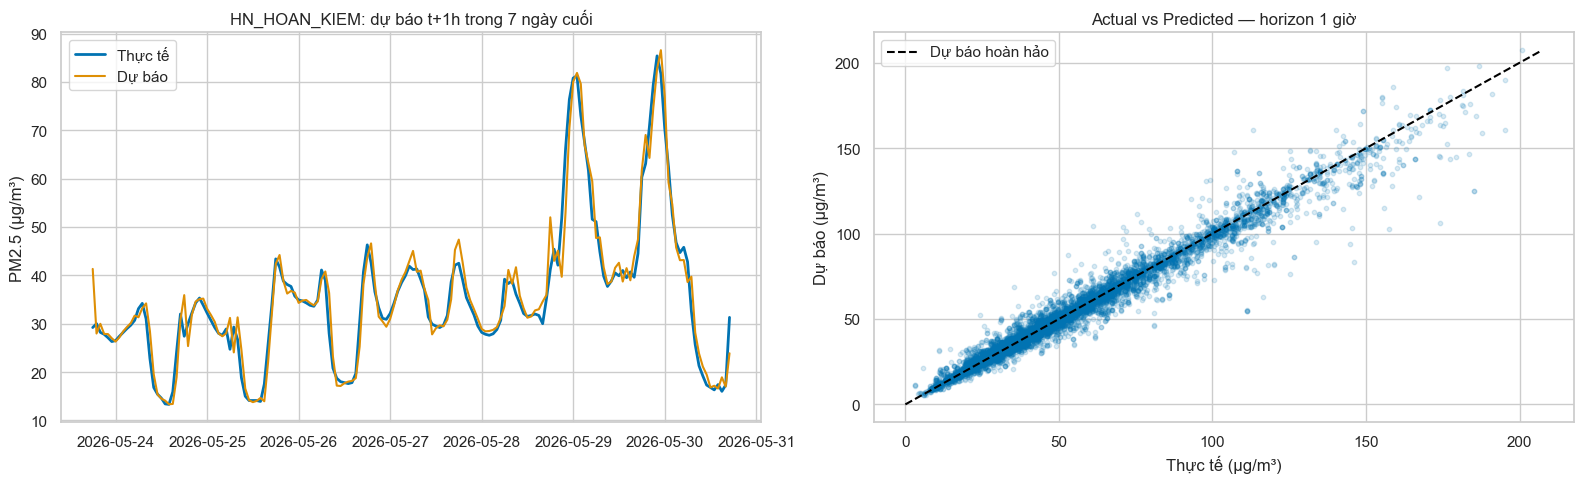

In [7]:
station = 'HN_HOAN_KIEM' if 'HN_HOAN_KIEM' in predictions['station_id'].unique() else predictions['station_id'].iloc[0]
station_week = predictions[predictions['station_id'].eq(station)].sort_values('timestamp').tail(24 * 7)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(station_week['timestamp'], station_week['actual_pm25_t_plus_1h'], label='Thực tế', linewidth=2)
axes[0].plot(station_week['timestamp'], station_week['predicted_pm25_t_plus_1h'], label='Dự báo', linewidth=1.5)
axes[0].set(title=f'{station}: dự báo t+1h trong 7 ngày cuối', ylabel='PM2.5 (µg/m³)', xlabel='')
axes[0].legend()

sample = predictions.sample(min(10000, len(predictions)), random_state=42)
axes[1].scatter(sample['actual_pm25_t_plus_1h'], sample['predicted_pm25_t_plus_1h'], alpha=0.15, s=10)
limit = max(sample['actual_pm25_t_plus_1h'].max(), sample['predicted_pm25_t_plus_1h'].max())
axes[1].plot([0, limit], [0, limit], '--', color='black', label='Dự báo hoàn hảo')
axes[1].set(title='Actual vs Predicted — horizon 1 giờ', xlabel='Thực tế (µg/m³)', ylabel='Dự báo (µg/m³)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Kết luận

In [8]:
winner = training_report['selected_model']
mean_mae = ranking.loc[ranking['model'].eq(winner), 'mean_MAE'].iloc[0]
one_hour = test_metrics.loc[test_metrics['horizon_hours'].eq(1)].iloc[0]
six_hour = test_metrics.loc[test_metrics['horizon_hours'].eq(6)].iloc[0]
display(Markdown(f'''
- **{winner}** là mô hình tốt nhất với mean MAE validation **{mean_mae:.2f} µg/m³**.
- Trên test, dự báo **1 giờ** đạt MAE **{one_hour.MAE:.2f}**, RMSE **{one_hour.RMSE:.2f}**, R² **{one_hour.R2:.3f}**.
- Dự báo **6 giờ** khó hơn: MAE **{six_hour.MAE:.2f}**, RMSE **{six_hour.RMSE:.2f}**, R² **{six_hour.R2:.3f}**.
- MAE và RMSE tăng theo horizon là hợp lý vì độ bất định tích lũy theo thời gian.
- Artifact dùng cho API nằm tại `artifacts/models/pm25_forecast.joblib`.
'''))


- **LightGBM** là mô hình tốt nhất với mean MAE validation **8.99 µg/m³**.
- Trên test, dự báo **1 giờ** đạt MAE **3.18**, RMSE **5.72**, R² **0.966**.
- Dự báo **6 giờ** khó hơn: MAE **12.28**, RMSE **17.58**, R² **0.677**.
- MAE và RMSE tăng theo horizon là hợp lý vì độ bất định tích lũy theo thời gian.
- Artifact dùng cho API nằm tại `artifacts/models/pm25_forecast.joblib`.
